In [9]:
import pandas as pd

In [10]:
df = pd.read_csv("WELFake_Dataset.csv")

In [11]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [12]:
df.shape

(72134, 4)

In [13]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [15]:
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['label'].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [18]:
df['label'].value_counts(normalize=True) * 100

label
1    51.440375
0    48.559625
Name: proportion, dtype: float64

In [19]:
print("Label 0 example:")
print(df[df['label'] == 0][['title', 'text']].iloc[0])

print("\n" + "="*80 + "\n")

print("Label 1 example:")
print(df[df['label'] == 1][['title', 'text']].iloc[0])

Label 0 example:
title    Bobby Jindal, raised Hindu, uses story of Chri...
text     A dozen politically active pastors came here f...
Name: 3, dtype: object


Label 1 example:
title    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
text     No comment is expected from Barack Obama Membe...
Name: 0, dtype: object


In [20]:
df = df.drop(columns = ['Unnamed: 0'])

In [21]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [22]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [23]:
df['title'] = df['title'].fillna('') 
df['text'] = df['text'].fillna('')

In [24]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [25]:
df['content'] = df['title'] + ' ' + df['text']  
df[['title', 'text', 'content', 'label']].head()

,title,text,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,,Did they post their votes for Hillary already?,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",SATAN 2: Russia unvelis an image of its terrif...,1


In [26]:
(df['content'].str.strip() == '').sum()

np.int64(0)

In [27]:
df = df[df['content'].str.strip() != '']

In [28]:
df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


In [29]:
df['content'].duplicated().sum()

np.int64(8456)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    72134 non-null  object
 1   text     72134 non-null  object
 2   label    72134 non-null  int64 
 3   content  72134 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.2+ MB


In [31]:
df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


In [32]:
duplicate_check = (
    df.groupby('content')['label']
    .nunique()
    .value_counts()
)

duplicate_check

label
1    63678
Name: count, dtype: int64

In [33]:
conflicting = (
    df.groupby('content')['label']
    .nunique()
)

conflicting[conflicting > 1].count()

np.int64(0)

In [34]:
df[df['content'].duplicated(keep=False)].sort_values('content')[['content', 'label']].head(10)

,content,label
33167,&quot;Virginia Roberts Affidavit&quot; a teen...,1
66441,&quot;Virginia Roberts Affidavit&quot; a teen...,1
30922,A leading US senator: US Supporting War in Sy...,1
269,A leading US senator: US Supporting War in Sy...,1
44493,A leading US senator: US Supporting War in Sy...,1
19606,A leading US senator: US Supporting War in Sy...,1
25143,A leading US senator: US Supporting War in Sy...,1
27398,A leading US senator: US Supporting War in Sy...,1
42026,A leading US senator: US Supporting War in Sy...,1
53308,Brilliant!,1


In [35]:
df = df.drop_duplicates(subset=['content'])

In [36]:
df.shape

(63678, 4)

In [37]:
df['content'].duplicated().sum()

np.int64(0)

In [38]:
df['label'].value_counts()

label
0    34791
1    28887
Name: count, dtype: int64

In [39]:
df['label'].value_counts(normalize=True) * 100

label
0    54.635824
1    45.364176
Name: proportion, dtype: float64

In [40]:
df = df.reset_index(drop=True)

In [41]:
df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


In [42]:
# EDA 

print("Total Articles:", len(df))
print("Total Fake News:", (df['label'] == 0).sum())
print("Total Real News:", (df['label'] == 1).sum())
print("Total Columns:", df.shape[1])

Total Articles: 63678
Total Fake News: 34791
Total Real News: 28887
Total Columns: 4


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

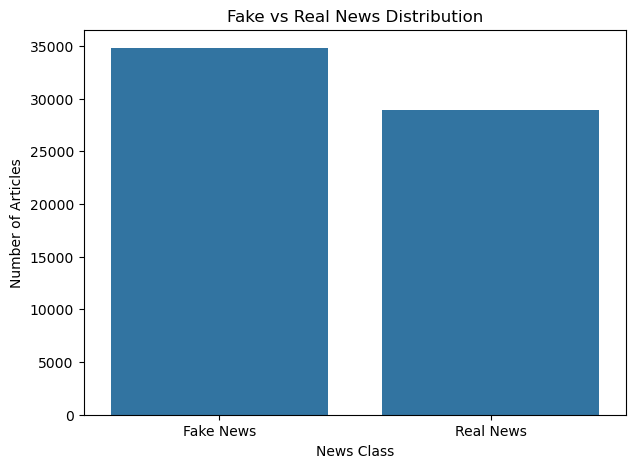

In [44]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='label')

plt.title('Fake vs Real News Distribution')
plt.xlabel('News Class')
plt.ylabel('Number of Articles')

plt.xticks([0, 1], ['Fake News', 'Real News'])

plt.show()

In [45]:
df['class_name'] = df['label'].map({
    0: 'Fake News',
    1: 'Real News'
}) 

df[['label', 'class_name']].head()

,label,class_name
0,1,Real News
1,1,Real News
2,1,Real News
3,0,Fake News
4,1,Real News


In [46]:
df['title_length'] = df['title'].str.len() 
df['title_length'].describe()

count    63678.000000
mean        74.568344
std         23.619850
min          0.000000
25%         61.000000
50%         72.000000
75%         86.000000
max        456.000000
Name: title_length, dtype: float64

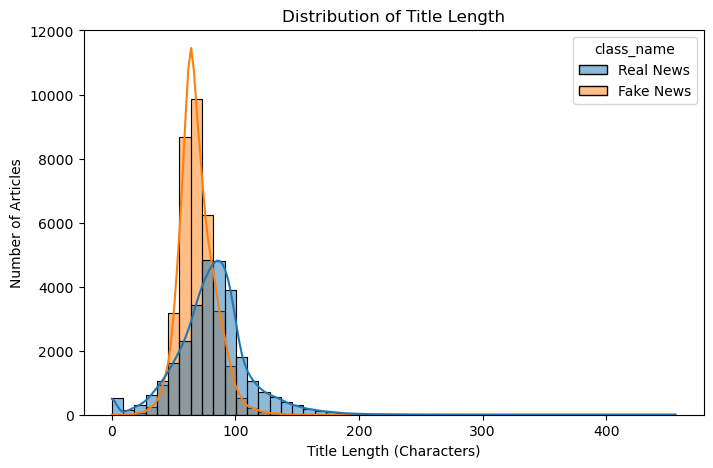

In [47]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='title_length',
    hue='class_name',
    bins=50,
    kde=True
)

plt.title('Distribution of Title Length')
plt.xlabel('Title Length (Characters)')
plt.ylabel('Number of Articles')

plt.show()

In [48]:
df['text_length'] = df['text'].str.len()

In [49]:
df['text_length'].describe()

count     63678.000000
mean       3276.752866
std        3636.269585
min           0.000000
25%        1428.000000
50%        2456.000000
75%        4095.000000
max      142961.000000
Name: text_length, dtype: float64

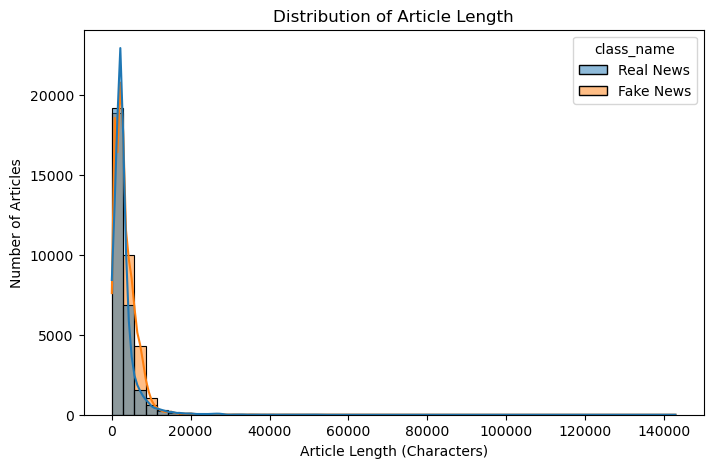

In [50]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='text_length',
    hue='class_name',
    bins=50,
    kde=True
)

plt.title('Distribution of Article Length')
plt.xlabel('Article Length (Characters)')
plt.ylabel('Number of Articles')

plt.show()

In [51]:
df.describe()

,label,title_length,text_length
count,63678.000000,63678.000000,63678.000000
mean,0.453642,74.568344,3276.752866
std,0.497850,23.619850,3636.269585
min,0.000000,0.000000,0.000000
25%,0.000000,61.000000,1428.000000
50%,0.000000,72.000000,2456.000000
75%,1.000000,86.000000,4095.000000
max,1.000000,456.000000,142961.000000


In [52]:
print("Total Articles:", len(df))
print("Total Fake News:", (df['label'] == 0).sum())
print("Total Real News:", (df['label'] == 1).sum())
print("Total Columns:", df.shape[1])

Total Articles: 63678
Total Fake News: 34791
Total Real News: 28887
Total Columns: 7


In [53]:
df['class_name'] = df['label'].map({
    0: 'Fake News',
    1: 'Real News'
}) 

df['title_length'] = df['title'].str.len()
df['title_length'].describe()

count    63678.000000
mean        74.568344
std         23.619850
min          0.000000
25%         61.000000
50%         72.000000
75%         86.000000
max        456.000000
Name: title_length, dtype: float64

In [54]:
df['text_length'] = df['text'].str.len()
df['text_length'].describe()

count     63678.000000
mean       3276.752866
std        3636.269585
min           0.000000
25%        1428.000000
50%        2456.000000
75%        4095.000000
max      142961.000000
Name: text_length, dtype: float64

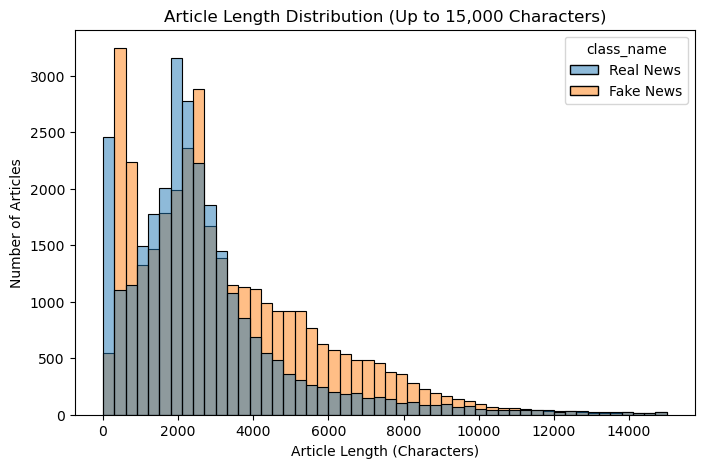

In [55]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df['text_length'] <= 15000],
    x='text_length',
    hue='class_name',
    bins=50
)

plt.title('Article Length Distribution (Up to 15,000 Characters)')
plt.xlabel('Article Length (Characters)')
plt.ylabel('Number of Articles')

plt.show()

In [56]:
df.groupby('class_name')[['title_length', 'text_length']].mean()

,title_length,text_length
class_name,,
Fake News,68.814952,3498.913685
Real News,81.497629,3009.186243


In [57]:
import re
from collections import Counter

In [58]:
import nltk
from nltk.corpus import stopwords

In [59]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [60]:
stop_words = set(stopwords.words('english'))

In [61]:
def clean_words(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

In [62]:
all_words = []

for text in df['content']:
    all_words.extend(clean_words(text))  

word_counts = Counter(all_words)

word_counts.most_common(20)

[('said', 220927),
 ('trump', 214444),
 ('would', 96260),
 ('president', 82533),
 ('people', 80848),
 ('one', 79360),
 ('new', 72576),
 ('clinton', 65744),
 ('state', 58847),
 ('also', 58291),
 ('like', 50503),
 ('obama', 47457),
 ('states', 46280),
 ('could', 45856),
 ('government', 45376),
 ('time', 44230),
 ('house', 43093),
 ('year', 41594),
 ('two', 41318),
 ('donald', 40671)]

In [63]:
fake_text = ' '.join(df[df['label'] == 0]['content'])
real_text = ' '.join(df[df['label'] == 1]['content'])

fake_words = clean_words(fake_text)
real_words = clean_words(real_text)

fake_word_counts = Counter(fake_words)
real_word_counts = Counter(real_words)

print("Top 20 words in Fake News:")
print(fake_word_counts.most_common(20))

print("\n" + "="*80 + "\n")

print("Top 20 words in Real News:")
print(real_word_counts.most_common(20))

Top 20 words in Fake News:
[('said', 183385), ('trump', 114986), ('would', 62420), ('president', 51761), ('new', 50025), ('one', 42931), ('people', 41772), ('state', 39600), ('also', 36405), ('states', 31627), ('government', 30292), ('house', 30193), ('could', 29970), ('clinton', 29825), ('reuters', 29159), ('year', 28229), ('two', 28123), ('united', 27592), ('republican', 27185), ('last', 26633)]


Top 20 words in Real News:
[('trump', 99458), ('people', 39076), ('said', 37542), ('one', 36429), ('clinton', 35919), ('would', 33840), ('president', 30772), ('hillary', 26263), ('like', 25629), ('obama', 23350), ('new', 22551), ('donald', 22116), ('also', 21886), ('even', 20892), ('time', 20767), ('state', 19247), ('news', 17008), ('election', 16549), ('white', 16033), ('american', 15982)]


In [64]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [75]:
import sys
!{sys.executable} -m pip install wordcloud --user

In [65]:
from wordcloud import WordCloud
print("WordCloud installed successfully!")

WordCloud installed successfully!


In [70]:
# Create Real News text
real_text = ' '.join(df[df['label'] == 1]['content'])

# Clean Real News words
real_words = clean_words(real_text)

print("Number of Real News words:", len(real_words))

Number of Real News words: 8086464


In [74]:
# Create Fake News text
fake_text = ' '.join(df[df['label'] == 0]['content'])

# Clean Fake News words
fake_words = clean_words(fake_text)

print("Number of Fake News words:", len(fake_words))

Number of Fake News words: 11462813


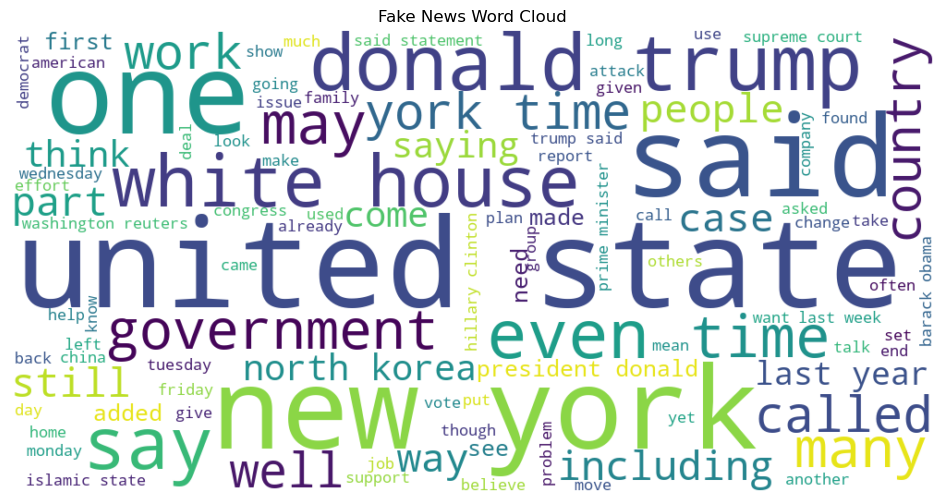

In [75]:
fake_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(' '.join(fake_words))

plt.figure(figsize=(12, 6))
plt.imshow(fake_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Fake News Word Cloud')

plt.show()

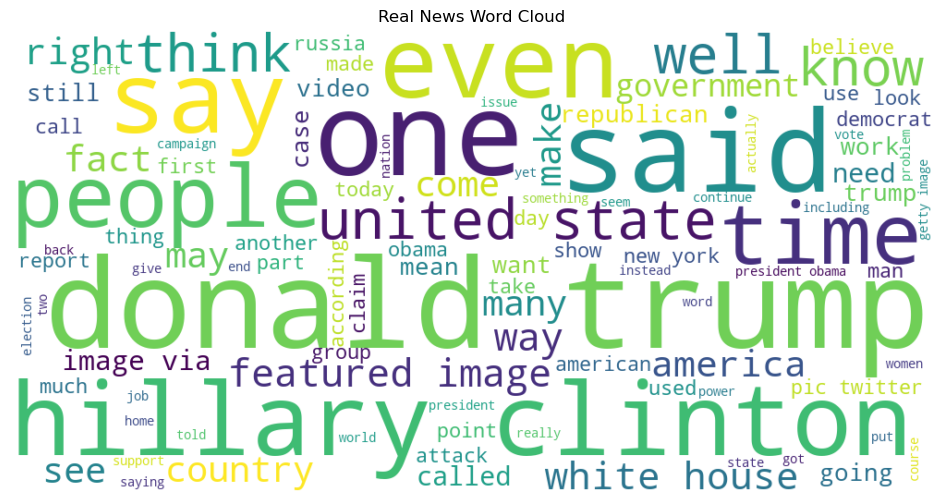

In [72]:
real_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(' '.join(real_words))

plt.figure(figsize=(12, 6))
plt.imshow(real_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Real News Word Cloud')

plt.show()

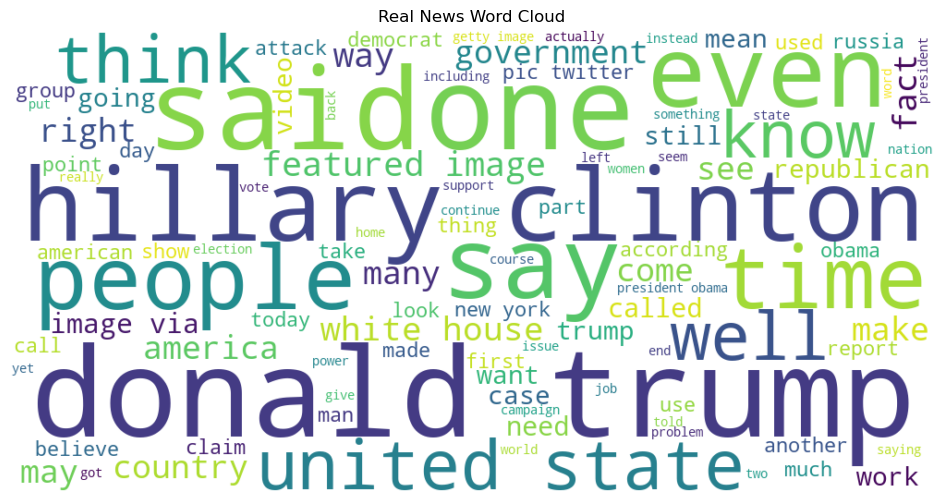

In [73]:
real_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(' '.join(real_words))

plt.figure(figsize=(12, 6))
plt.imshow(real_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Real News Word Cloud')

plt.show()

In [76]:
df['word_count'] = df['content'].apply(lambda x: len(clean_words(x)))

word_count_by_class = df.groupby('class_name')['word_count'].mean()

print(word_count_by_class)

class_name
Fake News    329.476388
Real News    279.934365
Name: word_count, dtype: float64


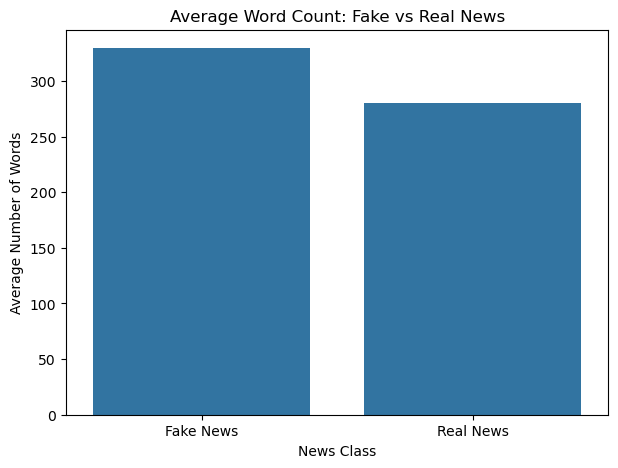

In [77]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=word_count_by_class.index,
    y=word_count_by_class.values
)

plt.title('Average Word Count: Fake vs Real News')
plt.xlabel('News Class')
plt.ylabel('Average Number of Words')
plt.show()

In [79]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Keep only alphabets and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Split into words
    words = text.split()
    
    # Remove stopwords and short words
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]
    
    return ' '.join(words)  

sample = df['content'].iloc[0]

print("Original:")
print(sample[:500])

print("\nCleaned:")
print(preprocess_text(sample)[:500])

Original:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizer

Cleaned:
law enforcement high alert following threats cops whites blacklivesmatter fyf terrorists video comment expected barack obama members fyf fukyoflag blacklivesmatter movements called lynching hanging white people cops encouraged others radio show tuesday night turn tide kill white people cops send message killing black people america one yoflag organizers called sunshine radio blog show hosted texas called sunshine ing opinion radio show snapshot fyf lolatwhitefear twitter pag

In [82]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers, punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Split into words
    words = text.split()

    # Remove stopwords and very short words
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(words)

In [83]:
df['clean_text'] = df['content'].apply(preprocess_text)

In [84]:
print(df.columns)

Index(['title', 'text', 'label', 'content', 'class_name', 'title_length',
       'text_length', 'word_count', 'clean_text'],
      dtype='object')


In [85]:
df[['content', 'clean_text']].head()

,content,clean_text
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement high alert following threats c...
1,Did they post their votes for Hillary already?,post votes hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama attorney general says charl...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story christian...
4,SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis image terrifying new supe...


In [86]:
print("Empty cleaned texts:", (df['clean_text'].str.strip() == '').sum())

Empty cleaned texts: 56


In [87]:
print("Rows before removing empty texts:", len(df))

df = df[df['clean_text'].str.strip() != ''].copy()

df.reset_index(drop=True, inplace=True)

print("Rows after removing empty texts:", len(df))

Rows before removing empty texts: 63678
Rows after removing empty texts: 63622


In [88]:
print("Empty cleaned texts:", (df['clean_text'].str.strip() == '').sum())

Empty cleaned texts: 0


In [89]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)  

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 50897
Testing samples: 12725


In [90]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
label
0    27832
1    23065
Name: count, dtype: int64

Testing class distribution:
label
0    6959
1    5766
Name: count, dtype: int64


In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer  

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
) 

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test) 

In [100]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (50897, 50000)
Testing TF-IDF shape: (12725, 50000)


In [101]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [102]:
# Make predictions on test data
y_pred = lr_model.predict(X_test_tfidf)

print("Predictions completed successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed successfully!
First 20 predictions:
[0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0]


In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.9601571709233792
Precision: 0.9594618207233968
Recall   : 0.9523066250433576
F1 Score : 0.9558708329706675

Confusion Matrix:
[[6727  232]
 [ 275 5491]]


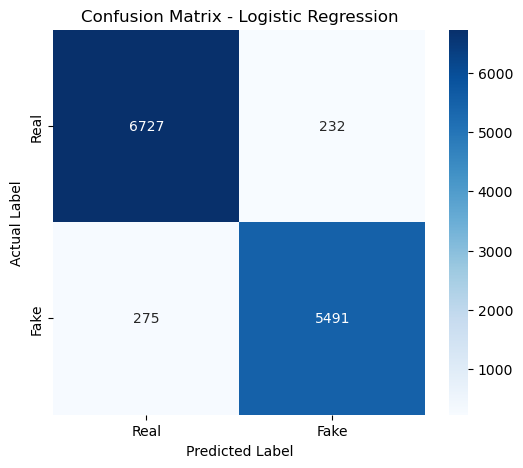

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [106]:
import numpy as np
import pandas as pd

# Get feature names from TF-IDF
feature_names = np.array(tfidf.get_feature_names_out())

# Get Logistic Regression coefficients
coefficients = lr_model.coef_[0]

# Top features associated with Fake News
top_fake_indices = np.argsort(coefficients)[-20:][::-1]

# Top features associated with Real News
top_real_indices = np.argsort(coefficients)[:20]

print("Top 20 Features Associated with Fake News:")
for i in top_fake_indices:
    print(feature_names[i], ":", coefficients[i])

print("\nTop 20 Features Associated with Real News:")
for i in top_real_indices:
    print(feature_names[i], ":", coefficients[i])

Top 20 Features Associated with Fake News:
via : 16.398150387030654
video : 10.437637396453743
featured image : 8.414338074981538
image : 8.179541317047875
featured : 7.709467090825539
october : 7.59337930809918
image via : 6.65915983487818
twitter com : 6.471303761133116
hillary : 6.2990172882297815
read : 6.139665810154504
november : 6.119684293658586
getty : 5.724275098288998
getty images : 5.436925564443871
watch : 5.051865373411753
com : 4.96664686897405
breaking : 4.585835775011763
america : 4.295520602030618
anti : 4.212729643928474
photo : 4.193685513749846
via breitbart : 3.887029298016434

Top 20 Features Associated with Real News:
reuters : -22.660383839236466
breitbart : -14.732335623543364
said : -14.35440920777859
washington reuters : -8.434658207005716
york times : -7.588444182300444
president donald : -7.350988382953487
follow : -6.637102851103515
twitter : -6.137222791820165
new york : -5.372417520471008
york : -5.253884207429896
thursday : -5.222163321854324
friday : 

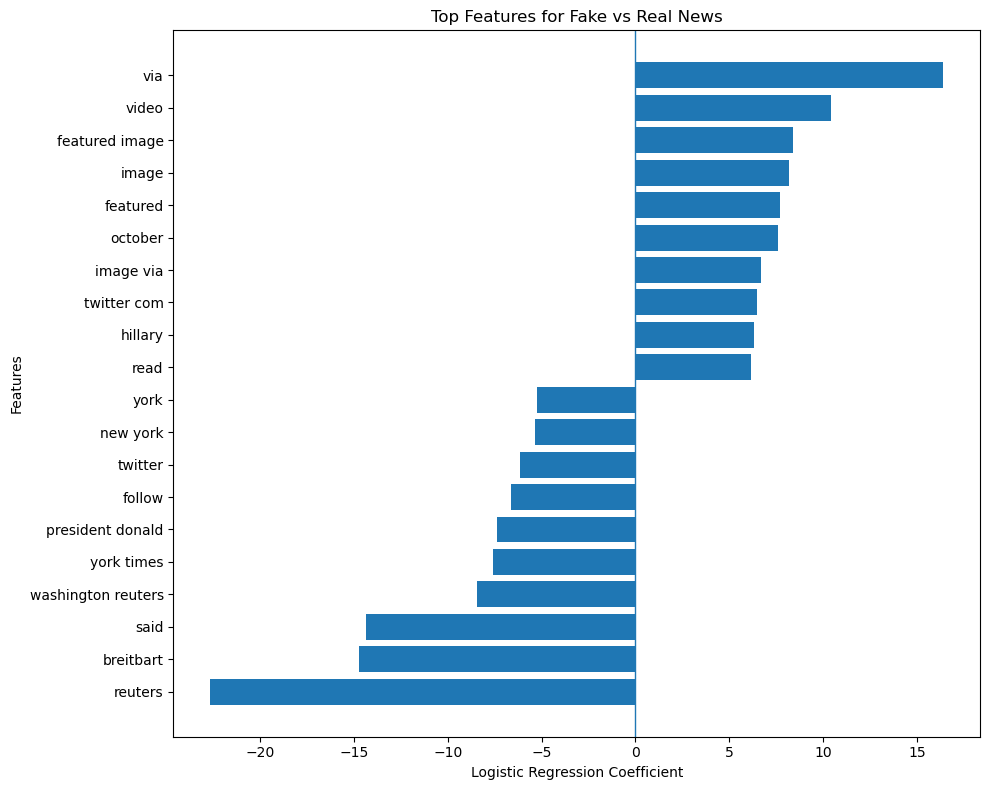

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 Fake News features
fake_indices = np.argsort(coefficients)[-10:]
fake_features = feature_names[fake_indices]
fake_coefficients = coefficients[fake_indices]

# Top 10 Real News features
real_indices = np.argsort(coefficients)[:10]
real_features = feature_names[real_indices]
real_coefficients = coefficients[real_indices]

# Combine features
features = np.concatenate([real_features, fake_features])
values = np.concatenate([real_coefficients, fake_coefficients])

# Plot
plt.figure(figsize=(10, 8))

plt.barh(features, values)

plt.axvline(x=0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Features")
plt.title("Top Features for Fake vs Real News")

plt.tight_layout()
plt.show()

In [108]:
# Test the model with a new news article

sample_news = """
The government announced a new policy today to improve digital education
and provide better access to online learning resources for students.
"""

# Convert the news into TF-IDF
sample_tfidf = tfidf.transform([sample_news])

# Predict
prediction = lr_model.predict(sample_tfidf)[0]

# Display result
if prediction == 1:
    print("Prediction: FAKE NEWS")
else:
    print("Prediction: REAL NEWS")

Prediction: FAKE NEWS


In [109]:
def predict_news(news_text):
    # Convert text into TF-IDF
    news_tfidf = tfidf.transform([news_text])
    
    # Make prediction
    prediction = lr_model.predict(news_tfidf)[0]
    
    # Get prediction probability
    probability = lr_model.predict_proba(news_tfidf)[0]
    
    if prediction == 1:
        result = "FAKE NEWS"
    else:
        result = "REAL NEWS"
    
    return result, probability


# Test the function
news = """
Scientists announced a new research study showing improvements
in renewable energy technology.
"""

result, probability = predict_news(news)

print("Prediction:", result)
print("Real News Probability:", round(probability[0] * 100, 2), "%")
print("Fake News Probability:", round(probability[1] * 100, 2), "%")

Prediction: FAKE NEWS
Real News Probability: 30.52 %
Fake News Probability: 69.48 %


In [110]:
import joblib

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save Logistic Regression model
joblib.dump(lr_model, "logistic_regression_model.pkl")

print("TF-IDF vectorizer saved successfully!")
print("Logistic Regression model saved successfully!")

TF-IDF vectorizer saved successfully!
Logistic Regression model saved successfully!


In [111]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\Lenovo

Files in this folder:
['.anaconda', '.aws', '.azure', '.bash_history', '.cache', '.cagent', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.docker', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.streamlit', '.vscode', '.vscode-shared', 'ai4i2020.csv', 'AppData', 'Application Data', 'coding c++', 'Contacts', 'Cookies', 'Covid Mini Project Analysis.ipynb', 'CrossDevice', 'Documents', 'Downloads', 'DV Practicals.ipynb', 'Fake_News_Detection.ipynb', 'FASTAPI', 'Favorites', 'golf.csv.xlsx', 'Heart Data Analysis.ipynb', 'heart.csv', 'insurance data.ipynb', 'insurance.csv', 'Links', 'Local Settings', 'logistic_regression_model.pkl', 'Microsoft', 'miktex-console.lock', 'ML Decision Tree.ipynb', 'ML Project.ipynb', 'Music', 'My Documents', 'NetHood', 'New folder', 'New folder (2)', 'New folder (3)', 'NLP Corpus.ipynb', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{a626b650-2e98-